# GW170817: Posterior plot comparison

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import bilby
import pandas as pd
import numpy as np
import seaborn as sns
from bilby.gw.result import CBCResult
import matplotlib.lines as mlines
from kde_contour import kdeplot_2d_clevels

### Waveforms: TaylorF2Ecck, TaylorF2Ecc 3PN, TaylorF2Ecc 3.5PN

In [2]:
rng = np.random.default_rng(12345)

sns.set_theme(palette='colorblind', font_scale=1.5)

# Ecck 3PN
result1 = bilby.result.read_in_result("../result_files/TF2Ecck_3PN_bayeswave_logprior.hdf5")
chirp_mass1 = result1.posterior["chirp_mass"].values
mass_ratio1 =  result1.posterior["mass_ratio"].values
e01 = result1.posterior["eccentricity"].values
m11 = (chirp_mass1*(1+mass_ratio1)**(1/5))/mass_ratio1**(3/5)
m21 = chirp_mass1*mass_ratio1**(2/5)*(1+mass_ratio1)**(1/5)
mtot1 = m11 + m21
eta1 = (m11*m21)/(mtot1**2)

# Ecc 3PN
result2 = bilby.result.read_in_result("../result_files/TF2Ecc_3PN_bayeswave_logprior.hdf5")
chirp_mass2 = result2.posterior["chirp_mass"].values
mass_ratio2 =  result2.posterior["mass_ratio"].values
e02 = result2.posterior["eccentricity"].values
m12 = (chirp_mass2*(1+mass_ratio2)**(1/5))/mass_ratio2**(3/5)
m22 = chirp_mass2*mass_ratio2**(2/5)*(1+mass_ratio2)**(1/5)
mtot2 = m12 + m22
eta2 = (m12*m22)/(mtot2**2)

# 8078 4423 4114 14858 28107
nsamples = min(len(mtot1), len(mtot2))

# make dataframes
data1 = np.transpose(np.array([mtot1, eta1, e01]))
df1 = pd.DataFrame(data1, columns=['mtot', 'eta', 'e0'])
result_ecck = df1.sample(nsamples, random_state=rng)
result_ecck[""] = "Ecck 3PN"
result_ecck['mtot'] = result_ecck['mtot']
result_ecck["e0"] = result_ecck["e0"]
result_ecck['eta'] = result_ecck['eta']

data2 = np.transpose(np.array([mtot2, eta2,e02]))
df2 = pd.DataFrame(data2, columns=['mtot', 'eta', 'e0'])
result_ecc3PN = df2.sample(nsamples, random_state=rng)
result_ecc3PN[""] = "Ecc 3PN"
result_ecc3PN["e0"] = result_ecc3PN["e0"]
result_ecc3PN['mtot'] = result_ecc3PN['mtot']
result_ecc3PN['eta'] = result_ecc3PN['eta']

result = pd.concat([result_ecck, result_ecc3PN],ignore_index=True)

In [20]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'backend': 'Agg',
    'savefig.dpi': 300,
    'grid.alpha': 0.5,
    'path.simplify': True,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    'mathtext.fontset': 'custom',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 1,
    'ytick.minor.width': 1,
    'lines.markeredgewidth': 1,
    'legend.numpoints': 1,
    'legend.frameon': False,
    'legend.handletextpad': 0.3
})

vars = ['mtot', 'eta', 'e0']
waveforms = ['Ecck 3PN', 'Ecc 3PN']
palette = {'Ecck 3PN': 'C0', 'Ecc 3PN': 'C1'}

diag_fill_alpha = 0.15
g = sns.pairplot(
    result,
    vars=vars,
    hue='',
    palette=palette,
    corner=True,
    kind='scatter',
    plot_kws=dict(marker='.', alpha=0.0, s=5),
    diag_kind='kde',
    diag_kws={'alpha': diag_fill_alpha, 'linewidth': 0.8, 'bw_adjust': 1.0},
    height=2.0,
)

contour_levels = np.sort([0.864, 0.393])
for i, row_var in enumerate(vars):
    for j, col_var in enumerate(vars):
        if i > j:
            ax = g.axes[i, j]
            for waveform, color in palette.items():
                subset = result[result[''] == waveform]
                kdeplot_2d_clevels(
                    xs=subset[col_var],
                    ys=subset[row_var],
                    levels=contour_levels,
                    ax=ax,
                    color=color,
                    linewidths=0.8,
                    auto_bound=False,
                    bw_method=0.4,
                )

if g._legend is not None:
    g._legend.remove()

/Users/phurailatpamhemantakumar/anaconda3/envs/igwn/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/phurailatpamhemantakumar/anaconda3/envs/igwn/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/phurailatpamhemantakumar/anaconda3/envs/igwn/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd

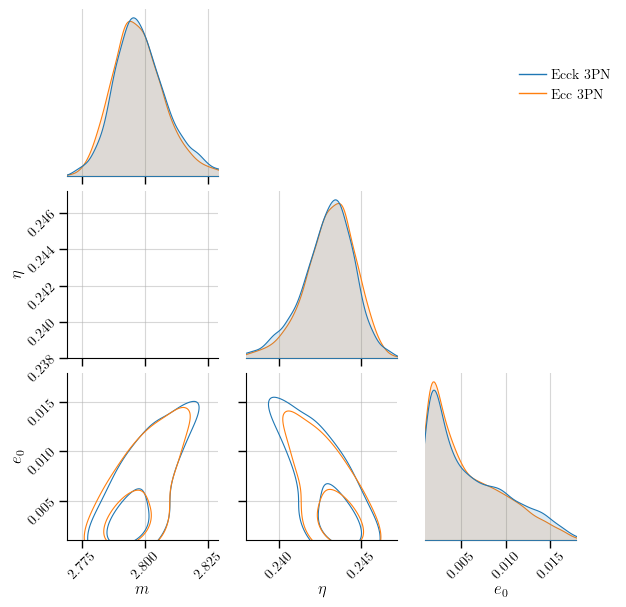

In [21]:
g.axes[2, 2].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 1].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='x', rotation=45, pad=1)
g.axes[2, 0].tick_params(axis='y', rotation=45, pad=1)
g.axes[1, 0].tick_params(axis='y', rotation=45, pad=1)

g.axes[2, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[2, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))
g.axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '%.3f' % x))  

g.axes[2,0].set_xlabel(r'$m$', labelpad=1, fontsize=12)
g.axes[1,0].set_ylabel(r'$\eta$', labelpad=1, fontsize=12)
g.axes[2,1].set_xlabel(r'$\eta$', labelpad=1, fontsize=12)
g.axes[2,0].set_ylabel(r'$e_0$', labelpad=1, fontsize=12)
g.axes[2,2].set_xlabel(r'$e_0$', labelpad=1, fontsize=12)

min_m = 2.769
max_m = 2.829
min_eta = 0.238
max_eta = 0.2472
min_e0 = 0.001
max_e0 = 0.0179
g.axes[2,0].set_xlim(min_m, max_m)
g.axes[2,0].set_ylim(min_e0, max_e0)
g.axes[2,2].set_xlim(min_e0, max_e0)
#
g.axes[2,1].set_xlim(min_eta, max_eta)
g.axes[1,0].set_ylim(min_eta, max_eta)

# add grid
for i in range(3):
    for j in range(3):
        if g.axes[i, j] is not None:
            g.axes[i, j].grid(True, which="both", ls="-", alpha=0.5)

# add legend with line colors
blue_line = mlines.Line2D([], [], color='C0', label='Ecck 3PN', linewidth=1)
orange_line = mlines.Line2D([], [], color='C1', label='Ecc 3PN', linewidth=1)
handles = [blue_line, orange_line]
labels = [h.get_label() for h in handles] 
g.fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0., 0.9, 0.9, .0), ncol=1) # Adjust loc and ncol as needed

g.savefig("GW170817_mtot_eta_e0_logprior.pdf", bbox_inches="tight", dpi=300)
g.savefig("GW170817_mtot_eta_e0_logprior.svg", bbox_inches="tight", dpi=300)
plt.show()

* You don't see the $\eta$ vs $m$ contour because the KDE is too narrow.

* The contour plots of $e_0$ vs $m$ and $e_0$ vs $\eta$ are later crop out using `Affinity Designer` software and create the Figure 5.